In [4]:
IMAGE_SIZE = 224  # Change if different
NORM_MEAN = [0.485, 0.456, 0.406]  # Change if different
NORM_STD = [0.229, 0.224, 0.225]   # Change if different

Loading model...
Validating on 1391 pure Hand/Shoulder images...
✓ Saved: figure1_body_confusion_matrix.png


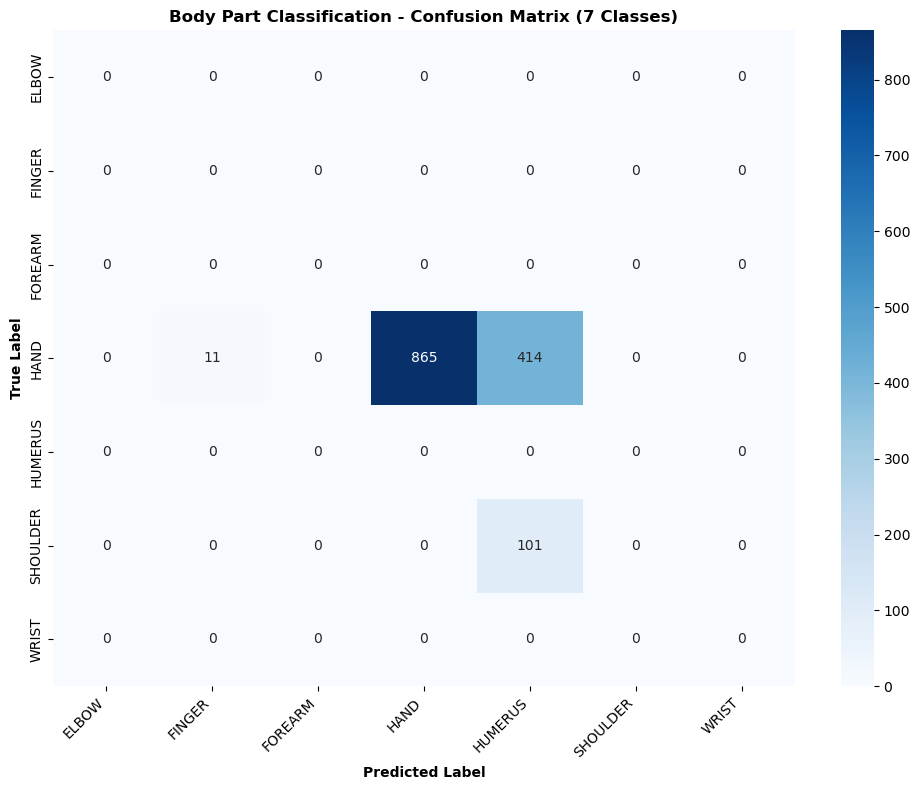

✓ Saved: figure2_abnormality_metrics.png


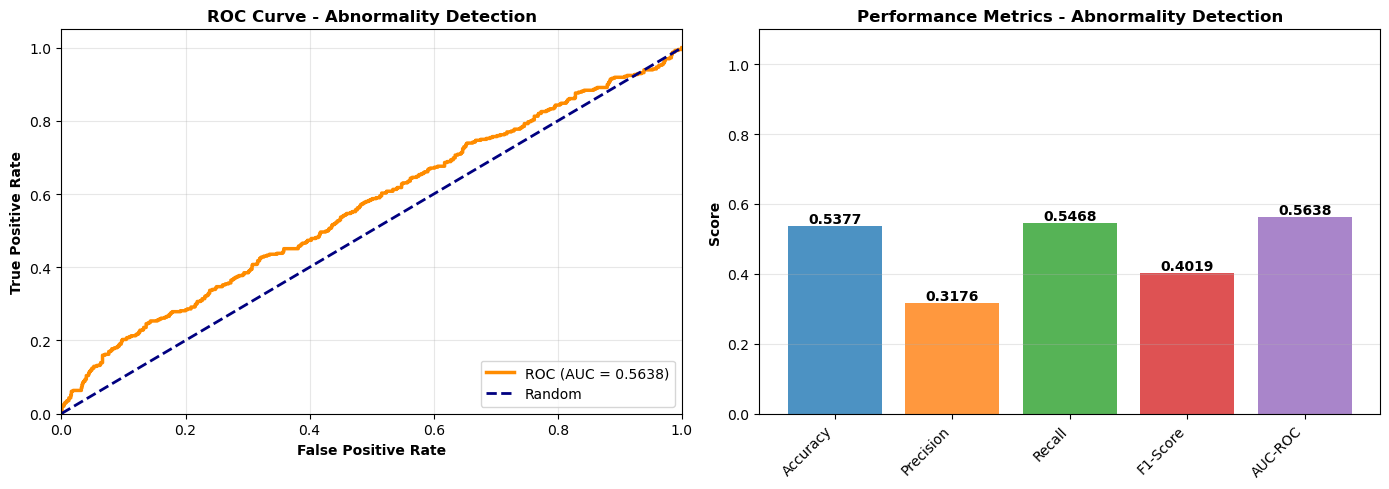

✓ Saved: figure3_class_distribution.png


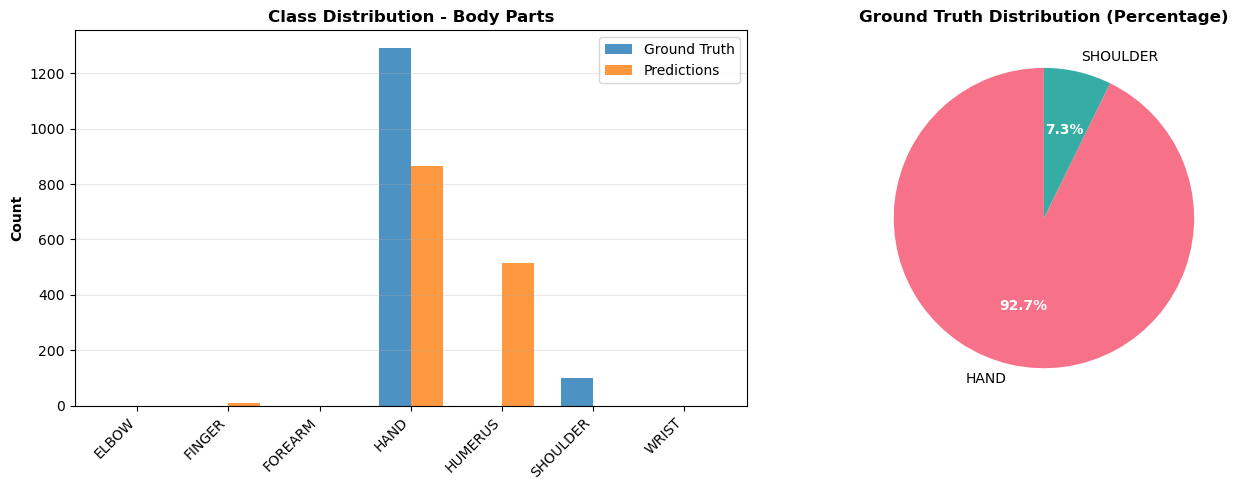

/home/kyq5rs/.conda/envs/my_mlenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/kyq5rs/.conda/envs/my_mlenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/kyq5rs/.conda/envs/my_mlenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()

✓ Saved: figure4_classification_report.png


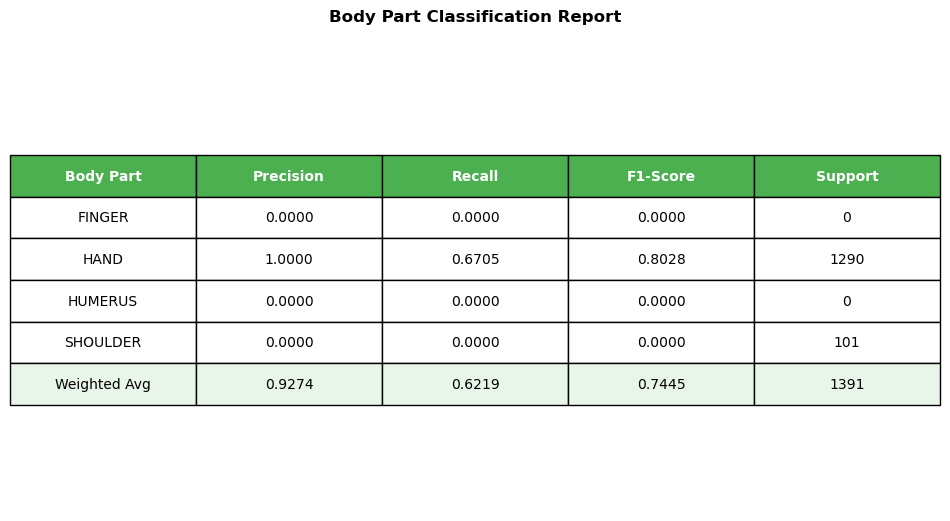

✓ Saved: figure5_abnormality_confusion_matrix.png


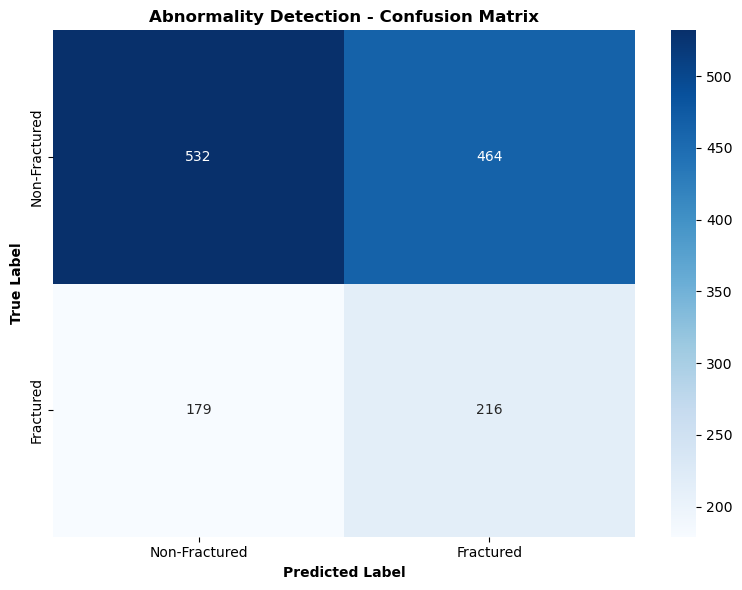


                               EVALUATION SUMMARY                               

[BODY PART CLASSIFICATION]
  Accuracy: 0.6219
  Total Samples: 1391

[ABNORMALITY DETECTION]
  Accuracy: 0.5377
  Precision: 0.3176
  Recall: 0.5468
  F1-Score: 0.4019
  AUC-ROC: 0.5638

[CLASSIFICATION REPORT - BODY PARTS]
              precision    recall  f1-score   support

      FINGER     0.0000    0.0000    0.0000         0
        HAND     1.0000    0.6705    0.8028      1290
     HUMERUS     0.0000    0.0000    0.0000         0
    SHOULDER     0.0000    0.0000    0.0000       101

    accuracy                         0.6219      1391
   macro avg     0.2500    0.1676    0.2007      1391
weighted avg     0.9274    0.6219    0.7445      1391


[CLASSIFICATION REPORT - ABNORMALITY]
               precision    recall  f1-score   support

Non-Fractured     0.7482    0.5341    0.6233       996
    Fractured     0.3176    0.5468    0.4019       395

     accuracy                         0.5377      13

/home/kyq5rs/.conda/envs/my_mlenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/kyq5rs/.conda/envs/my_mlenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/kyq5rs/.conda/envs/my_mlenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()

In [5]:
import os
import sys
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, classification_report, confusion_matrix,
                             roc_curve, auc, roc_auc_score)
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

SEED = 40
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


# ============================================================================
# CONFIGURATION & MAPPING
# ============================================================================
MODEL_PATH = Path('./final_model_multi_convnext.pth')
IMG_DIR = Path('./fracatlas_images')
CSV_PATH = Path('./fracatlas_dataset.csv')
OUTPUT_DIR = Path('./fracatlas_results')

IMAGE_SIZE = 224
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD = [0.229, 0.224, 0.225]
BATCH_SIZE = 32

# EXACT MAPPING FROM TRAINING
MURA_MAP = {
    0: 'ELBOW',
    1: 'FINGER',
    2: 'FOREARM',
    3: 'HAND',
    4: 'HUMERUS',
    5: 'SHOULDER',
    6: 'WRIST'
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUTPUT_DIR.mkdir(exist_ok=True)
ImageFile.LOAD_TRUNCATED_IMAGES = True

# ============================================================================
# MODEL ARCHITECTURE
# ============================================================================
class Multi_ConvNeXt(nn.Module):
    def __init__(self, num_body_parts):
        super().__init__()
        self.convnext = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)
        self.anatomy_head = nn.Linear(768, num_body_parts)
        self.abnormal_head = nn.Linear(768, 1)

    def forward(self, x):
        x = self.convnext.features(x)
        x = self.convnext.avgpool(x)
        x = x.flatten(1)
        anatomy_logits = self.anatomy_head(x)
        abnormal_logits = self.abnormal_head(x).squeeze(1)
        return anatomy_logits, abnormal_logits

print("Loading model...")
multi_convnext = Multi_ConvNeXt(num_body_parts=7)
checkpoint = torch.load(MODEL_PATH, map_location=device)
multi_convnext.load_state_dict(checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint)
multi_convnext.to(device).eval()

# ============================================================================
# DATASET (Filtering for Hand vs Shoulder)
# ============================================================================
class FracAtlasDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe
        self.img_dir = Path(img_dir)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        
        # Only use PURE hand or PURE shoulder
        if row['hand'] == 1 and row['shoulder'] == 0:
            label = 3 # HAND
        elif row['shoulder'] == 1 and row['hand'] == 0:
            label = 5 # SHOULDER
        else: 
            return None

        status = 'fractured' if row['fractured'] == 1 else 'non_fractured'
        img_path = self.img_dir / status / row['image_id']
        
        try:
            image = Image.open(img_path).convert('RGB')
            if self.transform: image = self.transform(image)
            return {'image': image, 'body_part_label': label, 'fractured_label': row['fractured']}
        except: 
            return None

df = pd.read_csv(CSV_PATH)
df_filtered = df[((df['hand'] == 1) & (df['shoulder'] == 0)) | 
                 ((df['shoulder'] == 1) & (df['hand'] == 0))].copy()

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD)
])

dataset_full = FracAtlasDataset(df_filtered, IMG_DIR, test_transform)
valid_indices = [i for i, x in enumerate(dataset_full) if x is not None]
dataset = Subset(dataset_full, valid_indices)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

# ============================================================================
# EVALUATION LOOP
# ============================================================================
all_labels_bp, all_preds_bp = [], []
all_labels_fr, all_preds_fr = [], []
all_fr_probs = []

print(f"Validating on {len(dataset)} pure Hand/Shoulder images...")
with torch.no_grad():
    for batch in dataloader:
        images, bp_labels, fr_labels = batch['image'].to(device), batch['body_part_label'].to(device), batch['fractured_label'].to(device)
        bp_logits, fr_logits = multi_convnext(images)

        preds = torch.argmax(bp_logits, dim=1)
        
        all_preds_bp.extend(preds.cpu().numpy())
        all_labels_bp.extend(bp_labels.cpu().numpy())
        
        fr_probs = torch.sigmoid(fr_logits).cpu().numpy()
        all_fr_probs.extend(fr_probs)
        all_preds_fr.extend((fr_probs > 0.5).astype(int))
        all_labels_fr.extend(fr_labels.cpu().numpy())

all_preds_bp = np.array(all_preds_bp)
all_labels_bp = np.array(all_labels_bp)
all_preds_fr = np.array(all_preds_fr)
all_labels_fr = np.array(all_labels_fr)
all_fr_probs = np.array(all_fr_probs)

# ============================================================================
# FIGURE 1: BODY PART CLASSIFICATION - CONFUSION MATRIX (ALL 7 CLASSES)
# ============================================================================
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(all_labels_bp, all_preds_bp, labels=range(7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=True,
            xticklabels=[MURA_MAP[i] for i in range(7)],
            yticklabels=[MURA_MAP[i] for i in range(7)])
ax.set_title('Body Part Classification - Confusion Matrix (7 Classes)', fontweight='bold', fontsize=12)
ax.set_ylabel('True Label', fontweight='bold')
ax.set_xlabel('Predicted Label', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'figure1_body_confusion_matrix.png'), dpi=300, bbox_inches='tight')
print("✓ Saved: figure1_body_confusion_matrix.png")
plt.show()

# ============================================================================
# FIGURE 2: ABNORMALITY DETECTION - METRICS & ROC CURVE
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: ROC Curve
ax_roc = axes[0]
fpr, tpr, _ = roc_curve(all_labels_fr, all_fr_probs)
roc_auc = auc(fpr, tpr)
ax_roc.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC (AUC = {roc_auc:.4f})')
ax_roc.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
ax_roc.set_xlim([0.0, 1.0])
ax_roc.set_ylim([0.0, 1.05])
ax_roc.set_xlabel('False Positive Rate', fontweight='bold')
ax_roc.set_ylabel('True Positive Rate', fontweight='bold')
ax_roc.set_title('ROC Curve - Abnormality Detection', fontweight='bold')
ax_roc.legend(loc="lower right")
ax_roc.grid(alpha=0.3)

# Right: Performance Metrics
ax_metrics = axes[1]
acc_fr = accuracy_score(all_labels_fr, all_preds_fr)
prec_fr = precision_score(all_labels_fr, all_preds_fr, zero_division=0)
rec_fr = recall_score(all_labels_fr, all_preds_fr, zero_division=0)
f1_fr = f1_score(all_labels_fr, all_preds_fr, zero_division=0)

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
metrics_values = [acc_fr, prec_fr, rec_fr, f1_fr, roc_auc]

bars = ax_metrics.bar(metrics_names, metrics_values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'], alpha=0.8)
ax_metrics.set_ylabel('Score', fontweight='bold')
ax_metrics.set_title('Performance Metrics - Abnormality Detection', fontweight='bold')
ax_metrics.set_ylim([0, 1.1])
ax_metrics.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, val in zip(bars, metrics_values):
    height = bar.get_height()
    ax_metrics.text(bar.get_x() + bar.get_width()/2., height,
                    f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'figure2_abnormality_metrics.png'), dpi=300, bbox_inches='tight')
print("✓ Saved: figure2_abnormality_metrics.png")
plt.show()

# ============================================================================
# FIGURE 3: CLASS DISTRIBUTION - GROUND TRUTH VS PREDICTIONS
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

true_counts = [np.sum(all_labels_bp == i) for i in range(7)]
pred_counts = [np.sum(all_preds_bp == i) for i in range(7)]

# Bar chart
ax1 = axes[0]
x = np.arange(7)
width = 0.35
bars1 = ax1.bar(x - width/2, true_counts, width, label='Ground Truth', alpha=0.8)
bars2 = ax1.bar(x + width/2, pred_counts, width, label='Predictions', alpha=0.8)
ax1.set_ylabel('Count', fontweight='bold')
ax1.set_title('Class Distribution - Body Parts', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([MURA_MAP[i] for i in range(7)], rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Pie chart
ax2 = axes[1]
true_counts_nonzero = [c for c in true_counts if c > 0]
true_labels_nonzero = [MURA_MAP[i] for i, c in enumerate(true_counts) if c > 0]
colors = sns.color_palette("husl", len(true_counts_nonzero))
wedges, texts, autotexts = ax2.pie(true_counts_nonzero, labels=true_labels_nonzero, autopct='%1.1f%%',
                                     colors=colors, startangle=90)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
ax2.set_title('Ground Truth Distribution (Percentage)', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'figure3_class_distribution.png'), dpi=300, bbox_inches='tight')
print("✓ Saved: figure3_class_distribution.png")
plt.show()

# ============================================================================
# FIGURE 4: CLASSIFICATION REPORT TABLE
# ============================================================================
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('tight')
ax.axis('off')

# Body Part Classification Report
present_indices = sorted(list(set(all_labels_bp) | set(all_preds_bp)))
report_dict = classification_report(all_labels_bp, all_preds_bp, 
                                    labels=present_indices,
                                    target_names=[MURA_MAP[i] for i in present_indices],
                                    output_dict=True)

table_data = []
for idx in present_indices:
    label_name = MURA_MAP[idx]
    p = report_dict[label_name]['precision']
    r = report_dict[label_name]['recall']
    f1 = report_dict[label_name]['f1-score']
    sup = int(report_dict[label_name]['support'])
    table_data.append([label_name, f'{p:.4f}', f'{r:.4f}', f'{f1:.4f}', sup])

# Add weighted average row
table_data.append(['Weighted Avg', 
                   f"{report_dict['weighted avg']['precision']:.4f}",
                   f"{report_dict['weighted avg']['recall']:.4f}",
                   f"{report_dict['weighted avg']['f1-score']:.4f}",
                   int(report_dict['weighted avg']['support'])])

columns = ['Body Part', 'Precision', 'Recall', 'F1-Score', 'Support']
table = ax.table(cellText=table_data, colLabels=columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Style header
for i in range(len(columns)):
    table[(0, i)].set_facecolor('#4CAF50')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Style weighted avg row
last_row = len(table_data)
for i in range(len(columns)):
    table[(last_row, i)].set_facecolor('#E8F5E9')

plt.title('Body Part Classification Report', fontweight='bold', pad=20, fontsize=12)
plt.savefig(os.path.join(OUTPUT_DIR, 'figure4_classification_report.png'), dpi=300, bbox_inches='tight')
print("✓ Saved: figure4_classification_report.png")
plt.show()

# ============================================================================
# FIGURE 5: ABNORMALITY CONFUSION MATRIX
# ============================================================================
fig, ax = plt.subplots(figsize=(8, 6))
cm_fr = confusion_matrix(all_labels_fr, all_preds_fr)
sns.heatmap(cm_fr, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=True,
            xticklabels=['Non-Fractured', 'Fractured'],
            yticklabels=['Non-Fractured', 'Fractured'])
ax.set_title('Abnormality Detection - Confusion Matrix', fontweight='bold', fontsize=12)
ax.set_ylabel('True Label', fontweight='bold')
ax.set_xlabel('Predicted Label', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'figure5_abnormality_confusion_matrix.png'), dpi=300, bbox_inches='tight')
print("✓ Saved: figure5_abnormality_confusion_matrix.png")
plt.show()

# ============================================================================
# PRINT SUMMARY STATISTICS
# ============================================================================
print("\n" + "="*80)
print("EVALUATION SUMMARY".center(80))
print("="*80)

acc_bp = accuracy_score(all_labels_bp, all_preds_bp)
print(f"\n[BODY PART CLASSIFICATION]")
print(f"  Accuracy: {acc_bp:.4f}")
print(f"  Total Samples: {len(dataset)}")

print(f"\n[ABNORMALITY DETECTION]")
print(f"  Accuracy: {acc_fr:.4f}")
print(f"  Precision: {prec_fr:.4f}")
print(f"  Recall: {rec_fr:.4f}")
print(f"  F1-Score: {f1_fr:.4f}")
print(f"  AUC-ROC: {roc_auc:.4f}")

print("\n[CLASSIFICATION REPORT - BODY PARTS]")
print(classification_report(all_labels_bp, all_preds_bp, 
                          labels=present_indices,
                          target_names=[MURA_MAP[i] for i in present_indices],
                          digits=4))

print("\n[CLASSIFICATION REPORT - ABNORMALITY]")
print(classification_report(all_labels_fr, all_preds_fr, 
                          target_names=['Non-Fractured', 'Fractured'],
                          digits=4))

print("\n" + "="*80)
print(f"Analysis complete. All figures saved to: {OUTPUT_DIR}")
print("="*80)